In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [95]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [97]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

In [100]:
df.isnull().sum().sum()

np.int64(0)

In [101]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [102]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [103]:
df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [104]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [105]:
df['State'].value_counts()

,count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484


In [106]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean()

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


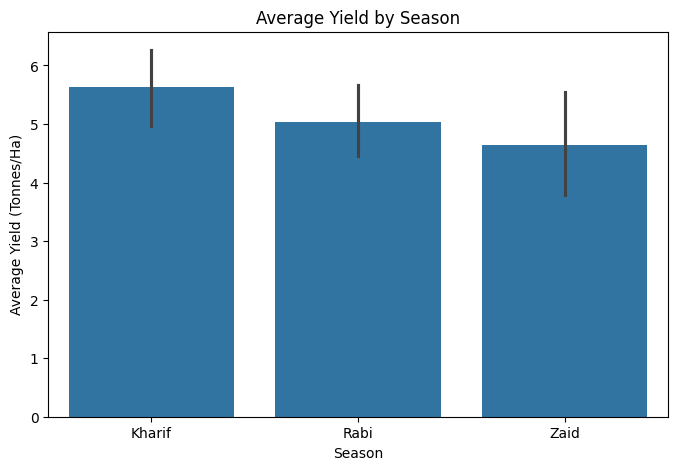

In [107]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

In [108]:
df.groupby('Season')['Production_Tonnes'].mean()

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


In [109]:
df.groupby('Season')['Profit_INR'].mean()

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


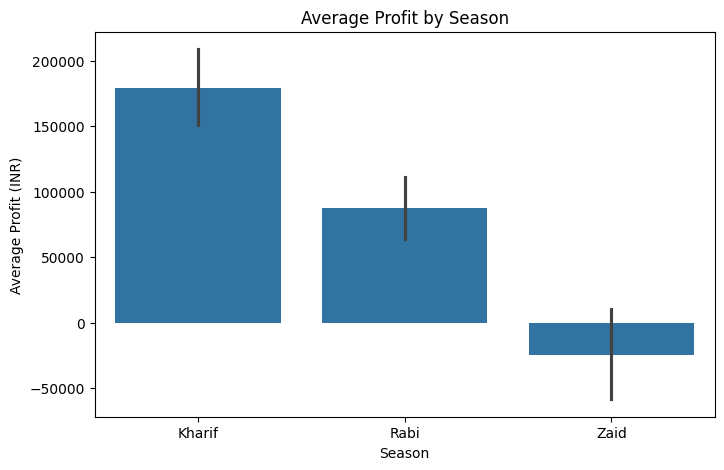

In [110]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Season', y='Profit_INR')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

In [111]:
df.groupby('Season')['Revenue_INR'].mean()

,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


In [112]:
df.groupby('Season')['Total_Cost_INR'].mean()

,Total_Cost_INR
Season,
Kharif,531804.408094
Rabi,513836.578365
Zaid,543976.728956


In [113]:
df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


In [114]:
df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().unstack()

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731459,1.374512,1.484974,2.966410,1.036063,2.698376,53.459120,2.253664
Rabi,1.465031,1.198358,1.233164,2.603648,0.875962,2.322847,43.286124,2.057468
Zaid,1.195312,0.960217,1.037778,2.290952,0.669677,1.900490,38.423922,1.748588


In [115]:
df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


In [116]:
df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.563784
Drip,6.267129
Sprinkler,4.669805
Flood,3.438853


In [117]:
df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct']].mean()

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct
Season,,,,
Kharif,849.199663,28.454019,71.812591,31.149859
Rabi,437.615366,23.489183,57.893178,24.069392
Zaid,304.654714,31.042088,52.012121,19.279630


In [118]:
df.corr(numeric_only=True)['Yield_Tonnes_Ha'].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


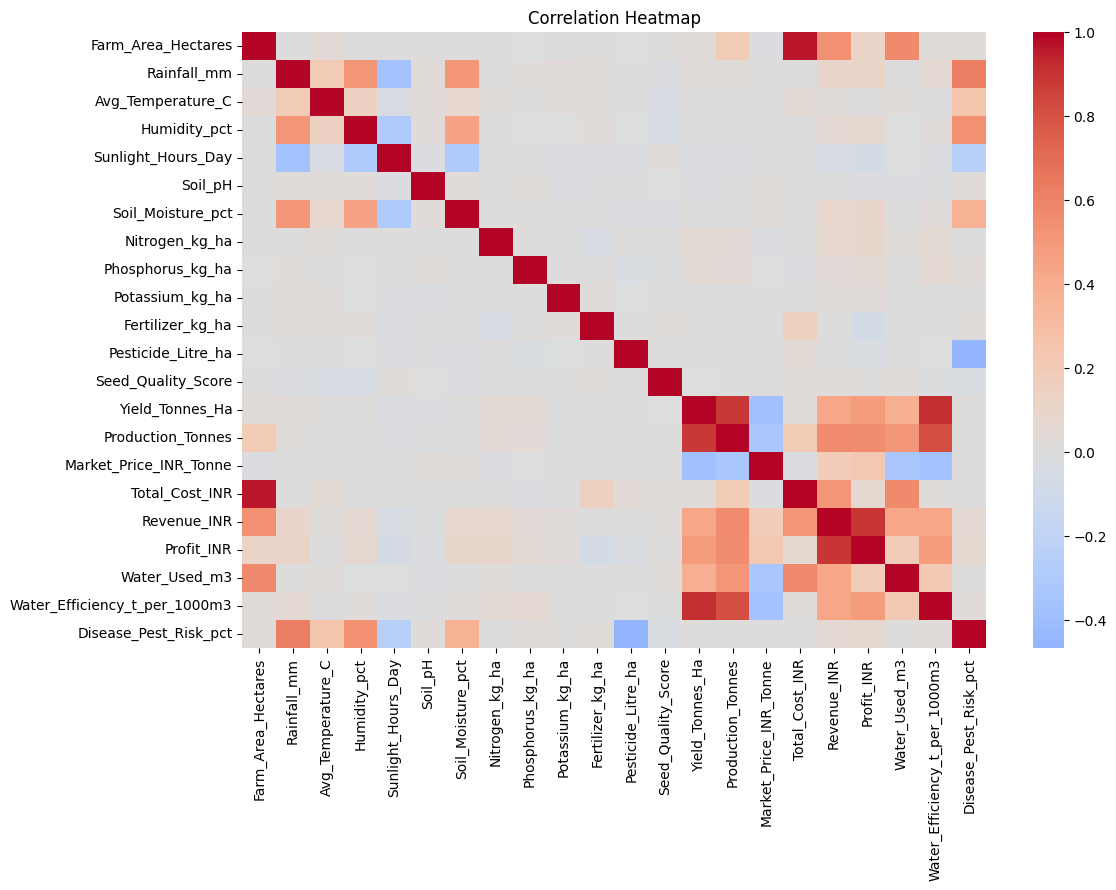

In [119]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [120]:
df.groupby('Irrigation_Method')['Profit_INR'].mean().sort_values(ascending=False)

,Profit_INR
Irrigation_Method,
Drip,219625.997814
Sprinkler,91121.079019
Rainfed,79050.365034
Flood,73354.022901


In [121]:
df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


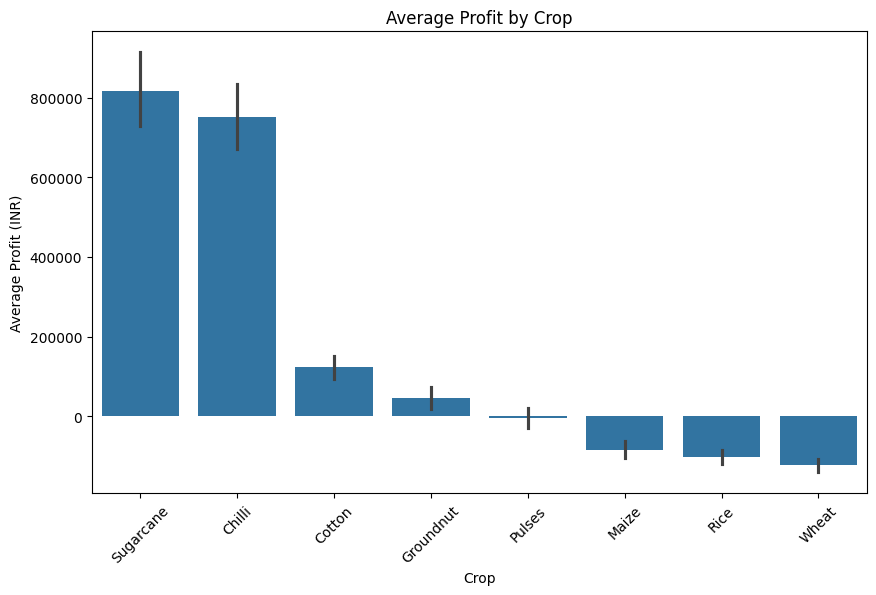

In [122]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='Crop',
    y='Profit_INR',
    estimator='mean',
    order=df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False).index
)
plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

In [123]:
df[['Farm_Area_Hectares', 'Yield_Tonnes_Ha']].corr()

,Farm_Area_Hectares,Yield_Tonnes_Ha
Farm_Area_Hectares,1.000000,0.030203
Yield_Tonnes_Ha,0.030203,1.000000


In [124]:
df[['Fertilizer_kg_ha', 'Yield_Tonnes_Ha']].corr()

,Fertilizer_kg_ha,Yield_Tonnes_Ha
Fertilizer_kg_ha,1.000000,0.000018
Yield_Tonnes_Ha,0.000018,1.000000


In [125]:
df[['Rainfall_mm', 'Yield_Tonnes_Ha']].corr()

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.030951
Yield_Tonnes_Ha,0.030951,1.000000


In [126]:
from scipy.stats import f_oneway

kharif = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = f_oneway(kharif, rabi, zaid)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [127]:
drip = df[df['Irrigation_Method'] == 'Drip']['Yield_Tonnes_Ha']
sprinkler = df[df['Irrigation_Method'] == 'Sprinkler']['Yield_Tonnes_Ha']
flood = df[df['Irrigation_Method'] == 'Flood']['Yield_Tonnes_Ha']
rainfed = df[df['Irrigation_Method'] == 'Rainfed']['Yield_Tonnes_Ha']

f_stat, p_value = f_oneway(drip, sprinkler, flood, rainfed)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 4.24554845996922
P-value: 0.005287932851309753


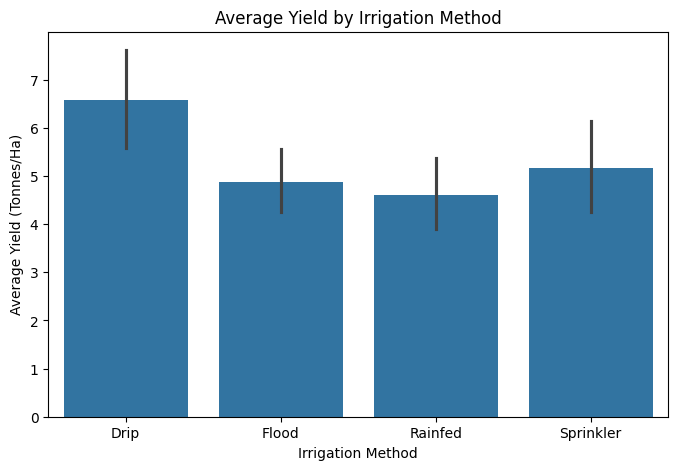

In [128]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha')
plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

In [129]:
df.groupby('Irrigation_Method')['Water_Used_m3'].mean().sort_values(ascending=False)

,Water_Used_m3
Irrigation_Method,
Flood,8026.472519
Sprinkler,6208.258856
Drip,5918.747541
Rainfed,3549.554275


In [130]:
df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().unstack()

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,317222.071605,133373.832203,158974.125270,116880.492212
Rabi,187843.221622,58824.798479,45232.479452,76502.068259
Zaid,21291.835714,-69786.778351,-79467.257143,57909.400000


In [131]:
df.groupby(['Season', 'Irrigation_Method']).size().unstack()

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


In [132]:
df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().idxmax()

('Kharif', 'Drip')

In [133]:
df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().max()

317222.07160493825

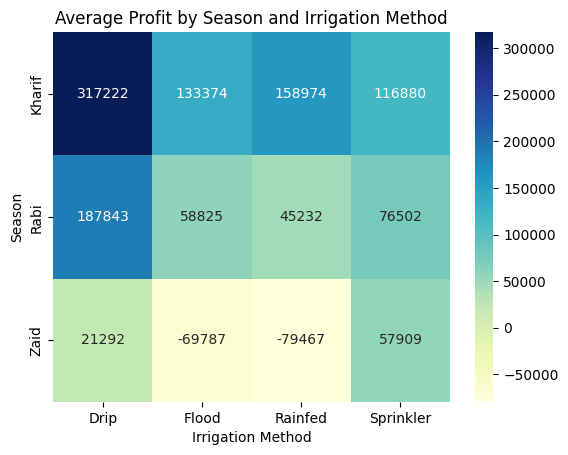

In [134]:
profit_pivot = df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().unstack()

sns.heatmap(profit_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Profit by Season and Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Season')
plt.show()

In [135]:
df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


In [136]:
df.groupby('Crop')['Revenue_INR'].mean().sort_values(ascending=False)

,Revenue_INR
Crop,
Sugarcane,1.371980e+06
Chilli,1.276777e+06
Cotton,6.394231e+05
Groundnut,5.429355e+05
Pulses,5.284659e+05
Maize,4.570680e+05
Rice,4.236153e+05
Wheat,4.001049e+05


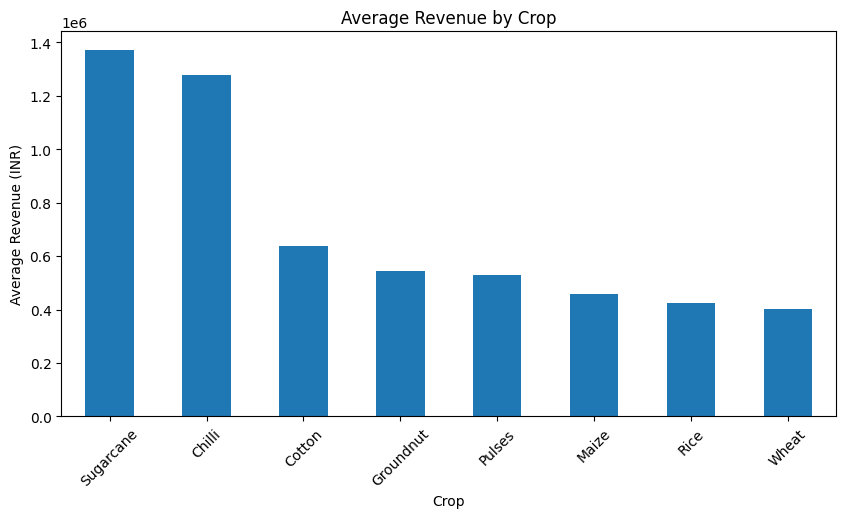

In [137]:
crop_revenue = df.groupby('Crop')['Revenue_INR'].mean().sort_values(ascending=False)

crop_revenue.plot(kind='bar', figsize=(10, 5), title='Average Revenue by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Revenue (INR)')
plt.xticks(rotation=45)
plt.show()

In [138]:
df.groupby('Crop')['Production_Tonnes'].mean().sort_values(ascending=False)

,Production_Tonnes
Crop,
Sugarcane,392.413016
Maize,21.781125
Rice,19.288623
Wheat,16.853909
Chilli,12.382888
Groundnut,9.655825
Cotton,9.395866
Pulses,7.401411


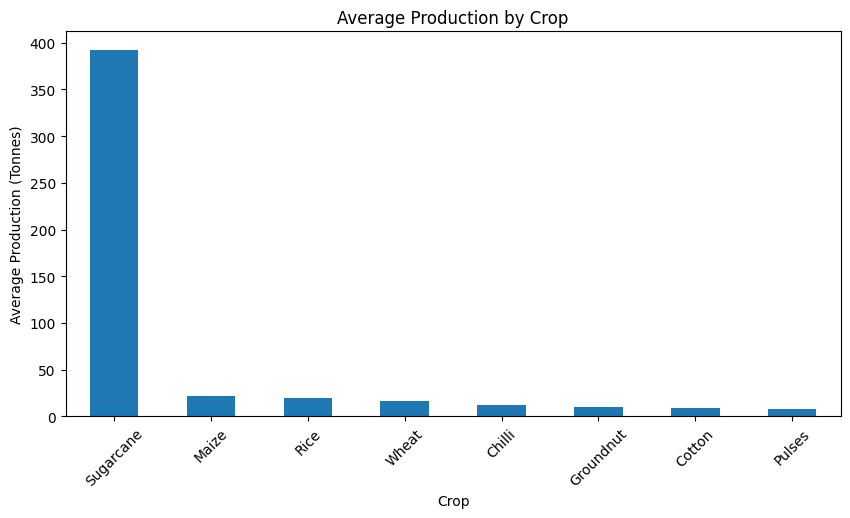

In [139]:
crop_production = df.groupby('Crop')['Production_Tonnes'].mean().sort_values(ascending=False)

crop_production.plot(kind='bar', figsize=(10, 5), title='Average Production by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Production (Tonnes)')
plt.xticks(rotation=45)
plt.show()

In [140]:
df.groupby('Crop')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().sort_values('Water_Efficiency_t_per_1000m3', ascending=False)

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Crop,,
Sugarcane,13897.704918,30.477672
Maize,4377.776770,5.602995
Wheat,4054.402280,4.628393
Groundnut,3459.535377,3.154795
Chilli,4577.468447,2.947709
Pulses,2833.665323,2.896504
Rice,10920.215942,1.946112
Cotton,5410.858268,1.938016


In [141]:
df[['Water_Used_m3', 'Production_Tonnes']].corr()

,Water_Used_m3,Production_Tonnes
Water_Used_m3,1.000000,0.515557
Production_Tonnes,0.515557,1.000000


In [142]:
df.groupby('Crop')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

,Disease_Pest_Risk_pct
Crop,
Wheat,47.854723
Pulses,46.570161
Rice,46.495797
Groundnut,46.289151
Chilli,46.062136
Cotton,45.974606
Maize,45.539564
Sugarcane,45.403934


In [143]:
df[['Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha']].corr()

,Disease_Pest_Risk_pct,Yield_Tonnes_Ha
Disease_Pest_Risk_pct,1.000000,0.014292
Yield_Tonnes_Ha,0.014292,1.000000


In [144]:
profit_combo = df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().sort_values(ascending=False)

profit_combo.head(5)

Season  Irrigation_Method
Kharif  Drip                 317222.071605
Rabi    Drip                 187843.221622
Kharif  Rainfed              158974.125270
        Flood                133373.832203
        Sprinkler            116880.492212
Name: Profit_INR, dtype: float64

In [145]:
df.groupby(['State', 'Crop'])['Profit_INR'].mean().sort_values(ascending=False).head(10)

,,Profit_INR
State,Crop,
Tamil Nadu,Sugarcane,979775.387097
Maharashtra,Chilli,929988.150943
Gujarat,Chilli,901790.217391
Maharashtra,Sugarcane,893729.305556
Andhra Pradesh,Sugarcane,867348.935484
Gujarat,Sugarcane,852212.476190
Madhya Pradesh,Sugarcane,796706.828571
Karnataka,Chilli,760005.480769
Tamil Nadu,Chilli,747757.909091


## Key Findings

- Kharif season recorded the highest average yield and production among the three seasons.
- Kharif also generated the highest average revenue and profit.
- Drip irrigation recorded the highest average yield and profit among the irrigation methods.
- Sugarcane had the highest average production, revenue, and profit among the crops.
- Tamil Nadu–Sugarcane was the most profitable State–Crop combination in the analysis.
- Water usage showed a moderate positive relationship with production.
- Disease and pest risk showed almost no linear relationship with yield in this dataset.
- Punjab recorded the highest average profit among the states.